# Example : control loop

In this example we explain how to us the control loop sub package of freegsnke. We will demonstrate the individual features and then look at running a validation test and a full dynamic simulation.

First we will follow the usual first steps of creating an tokamak, GS equilibrium and profiles. Then we will 
- create a sample control schedule, waveforms and VC schedule.
- demonstrate the use of the controller objects for Ip control an shape control
- run a validation test using the full control system
- run a dynamic simulation using the full control system



## import packages 

In [ ]:
import numpy as np
import pickle
import time
import os
import matplotlib.pyplot as plt
from copy import deepcopy

import freegs4e
from freegsnke import equilibrium_update, GSstaticsolver

%load_ext autoreload
%autoreload 2

## Create Machine and equilibrium

- set paths to config files
- create tokamak object
- create equilibrium object
- solve equilibrium

In [2]:
# set paths
os.environ["ACTIVE_COILS_PATH"] = (
    f"../machine_configs/MAST-U/MAST-U_like_active_coils.pickle"
)
os.environ["PASSIVE_COILS_PATH"] = (
    f"../machine_configs/MAST-U/MAST-U_like_passive_coils.pickle"
)
os.environ["WALL_PATH"] = f"../machine_configs/MAST-U/MAST-U_like_wall.pickle"
os.environ["LIMITER_PATH"] = f"../machine_configs/MAST-U/MAST-U_like_limiter.pickle"

In [3]:
# Now the machine can actually be built:
from freegsnke import build_machine

tokamak = build_machine.tokamak()

No probe configuration is provided


### create blank equilibrium and profiles

In [4]:
from freegsnke import equilibrium_update

eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.1,
    Rmax=2.0,  # Radial range
    Zmin=-2.2,
    Zmax=2.2,  # Vertical range
    nx=65,  # Number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
    ny=129,  # Number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
    # psi=plasma_psi
)

In [5]:
from freegsnke.jtor_update import ConstrainPaxisIp

profiles = ConstrainPaxisIp(
    eq=eq,  # equilibrium object
    paxis=8.1e3,  # profile object
    Ip=6.2e5,  # plasma current
    fvac=0.5,  # fvac = rB_{tor}
    alpha_m=1.8,  # profile function parameter
    alpha_n=1.2,  # profile function parameter
)

In [6]:
eq_copy = deepcopy(eq)
profiles_copy = deepcopy(profiles)

### set coil currents and solve equilibrium

We'll use the same sample currents as in previous examples.

In [7]:
with open("simple_diverted_currents_PaxisIp.pk", "rb") as f:
    current_values = pickle.load(f)

for key in current_values.keys():
    eq.tokamak[key].current = current_values[key]

# instantiate solver
from freegsnke import GSstaticsolver

GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

# Call solver and solve for equilibrium
GSStaticSolver.solve(
    eq=eq, profiles=profiles, constrain=None, target_relative_tolerance=1e-8, verbose=0
)

we can plot this equilibrium

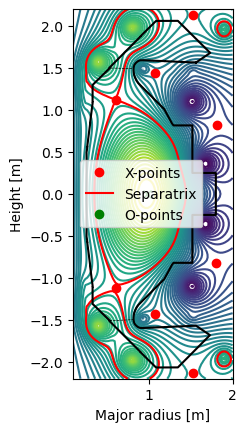

<Axes: xlabel='Major radius [m]', ylabel='Height [m]'>

In [8]:
from freegs4e.plotting import plotEquilibrium as plot_eqi

plot_eqi(eq, show=True)

The simulations will also make use of the non linear solver so we'll create that now here too.



In [9]:
from freegsnke.nonlinear_solve import nl_solver

stepping = nl_solver(
    eq=eq,
    profiles=profiles,
    full_timestep=5e-4,
    plasma_resistivity=1e-6,
    min_dIy_dI=0.1,
    max_mode_frequency=10**2.5,
)

# set initial conditions
stepping.initialize_from_ICs(eq, profiles)

Input 'max_mode_frequency' corresponds to 16 independent passive structure normal modes (in addition to the 12 active coils).
Linearising with respect to the currents - this may take a minute or two.
Mode removal is ON: the input 'min_dIy_dI' corresponds to keeping 24 out of the original 28 metal modes.
The linear growth rate of this equilibrium corresponds to a characteristic timescale of [0.00972219] s.
The solver's timestep has been set to 0.0005 as explicitly requested. Please compare this with the linear growth rate and reset if necessary.


## Creating a control schedule

We need to specify how we'd like the plasma to evolve in time. This is done by setting schedules and waveforms for the plasma current and shape targets. As a simplest example we'll set these to remain constant throughout the simulation. This data is stored as a dictionary and saved to pickle file. 

The schedule prescribes which quantites are to be controlled at which time. We need a schedule for the feedfoward and feedback shape control, and for Ip control.

The waveforms prescribe the values of the quantities at which the schedules are to be controlled. We also need waveforms for the feedforward and feedback shape control, and for Ip control. We'll use the same waveform for feedback and feedfoward (usually these will be the same)

We'll create two schedules for each, one where there is no control and one where there is, and we'll use the same waveform for both.

### Shape targets 

For the shape control we'll use the following targets:

[R_in, R_out, Rx_lower, Rs_lower_outer]



In [10]:
# blank schedule - target control is turned off
targ_schedule_1 = {
    0.0: [],
}

# schedule with target control on
targ_schedule_2 = {
    0.0: ["R_in", "R_out", "Rx_lower"],
    0.2: ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
}

# save to pickle

with open("./control_pickles/shape_schedule_off.pkl", "wb") as f:
    pickle.dump(targ_schedule_1, f)

with open("./control_pickles/shape_schedule_on.pkl", "wb") as f:
    pickle.dump(targ_schedule_2, f)

To create the waveform we'll start at the shape values of our start equilibrium. If we chose values too far away then the dynamic solver will not converge. We can use the VirtualCirucitHandling class to calculate the shape values of the equilibrium, as well as the VC itself. 

We'll need to instantiate the VirtualCirucitHandling class, and then call the calculate targets


In [11]:
# waveform for target control.
from freegsnke.virtual_circuits import VirtualCircuitHandling

VCH = VirtualCircuitHandling()
# assign solver to VCH
VCH.define_solver(solver=GSStaticSolver, target_relative_tolerance=1e-7)
targets_names, start_target_vals = VCH.calculate_targets(
    eq, targets=["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
)

shape_waveform_const = {target: {} for target in targets_names}
shape_waveform_const["R_in"]["times"] = [0.0]
shape_waveform_const["R_in"]["vals"] = [start_target_vals[0]]
shape_waveform_const["R_out"]["times"] = [0.0]
shape_waveform_const["R_out"]["vals"] = [start_target_vals[1]]
shape_waveform_const["Rx_lower"]["times"] = [0.0]
shape_waveform_const["Rx_lower"]["vals"] = [start_target_vals[2]]
shape_waveform_const["Rs_lower_outer"]["times"] = [0.0]
shape_waveform_const["Rs_lower_outer"]["vals"] = [start_target_vals[3]]

print(shape_waveform_const)
with open("./control_pickles/shape_waveform_const.pkl", "wb") as f:
    pickle.dump(shape_waveform_const, f)

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
{'R_in': {'times': [0.0], 'vals': [0.35260432187338564]}, 'R_out': {'times': [0.0], 'vals': [1.444953048829074]}, 'Rx_lower': {'times': [0.0], 'vals': [0.6064605929105276]}, 'Rs_lower_outer': {'times': [0.0], 'vals': [1.1165913256369715]}}


### Ip 
Now we repeat the process for Ip control. As with the shape control we'll set the waveform to keep the plasma current constant, starting from the initial equilibrium values.

In [12]:
# schedule with Ip control off
ip_schedule_1 = {
    0.0: [],
}

# schedule with Ip control on for al time.
ip_schedule_2 = {0.0: ["Ip"]}

with open("./control_pickles/ip_schedule_off.pkl", "wb") as f:
    pickle.dump(ip_schedule_1, f)

with open("./control_pickles/ip_schedule_on.pkl", "wb") as f:
    pickle.dump(ip_schedule_2, f)

In [13]:
# Ip waveform
ip_start = profiles.Ip
ip_waveform_const = {"Ip": {"times": [0.0], "vals": [ip_start]}}

with open("./control_pickles/ip_waveform_const.pkl", "wb") as f:
    pickle.dump(ip_waveform_const, f)

We also need a few other dictionaries we need to create. 
- CoilPerturbation waveform. These are coil currents which get added to requested control oens, but for now we'll just set this to zero. The simulator still require this as an input so we'll create the necessary empty waveforms now.
- ip_control_parameters : This describes the control sequence for the Ip, and contains values for feedforward Vloop, blends (for mixing feedfoward and feedback Vloop), Kp (proportional gains). For simplicity we'll again use a single constant value for these parameters. In general there'll be multiple values.

In [14]:
active_coils = eq.tokamak.coils_list[: eq.tokamak.n_active_coils]
print(active_coils)
coil_pert_schedule = {
    0.0: active_coils,
}
with open("./control_pickles/coil_pert_schedule.pkl", "wb") as f:
    pickle.dump(coil_pert_schedule, f)

timestamps = np.arange(0, 1, 0.05)
coil_pert_waveform = {
    coil: {"times": timestamps, "vals": np.zeros_like(timestamps)}
    for coil in active_coils
}

with open("./control_pickles/coil_pert_waveform.pkl", "wb") as f:
    pickle.dump(coil_pert_waveform, f)

['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5', 'P6']


In [15]:
# ip control parameters
ip_copntrol_params = {
    "Kp": {
        0: 1,
    },
    "Vloop": {
        0: 10050,
    },
    "blend": {
        0: 0.5,
    },
    "vc": np.array(
        [1, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.0]
    ),
}

with open("./control_pickles/ip_control_params.pkl", "wb") as f:
    pickle.dump(ip_copntrol_params, f)

Lastly we need the VC schedule. For simplicity we'll use only one VC for the entire simulation, but in general we'd use more. We'll create a VC built from the start equilibrium. Because we're using the VC class in freegsnke, we need to unpack the elements of this to store in the dictionary.

We can specify the coils and targets to be used in the VC. We'll use the default all active coils and set the targets to be those we are controlling.

In [16]:
VCH.calculate_VC(
    eq=eq,
    profiles=profiles,
    coils=[
        "Solenoid",
        "PX",
        "D1",
        "D2",
        "D3",
        "Dp",
        "D5",
        "D6",
        "D7",
        "P4",
        "P5",
        "P6",
    ],
    targets=["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    targets_options=None,
    non_standard_targets=None,
)

virtual_circuit = VCH.latest_VC
gains_arr = 0.5 * np.ones(4)  # target gains - set to 0.5 for all target for testing.
vc_dict = {
    "shape_matrix": virtual_circuit.shape_matrix,
    "vc_matrix": virtual_circuit.VCs_matrix,
    "targets": ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"],
    "coils": virtual_circuit.coils,
    "time_calc": 0.0,
    "time_stop": 10.0,  # set time stop to much longer than simulation time as we're only using one vc.
    "targets_val": virtual_circuit.targets_val,
    "input_currents": virtual_circuit.eq.tokamak.getCurrents(),
    "input_profile_pars": [],  # input_profile_pars - can be obtained from the profiles object
    "target_gains": gains_arr,
}

vc_schedule_dict = {0: vc_dict}  # single vc stored in dictionary

# save to pickle
with open("./control_pickles/vc_schedule.pkl", "wb") as f:
    pickle.dump(vc_schedule_dict, f)

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

## Control modules

NB. This part can be skipped on first reading if only interested in running a full simulation using the simulation functions.

In this section we'll look at the internal elements of the control modules, and how they are used to implement the control loops. 

The internals of the control loop are contained in the following modules:
- freegsnke.control_loop.target_scheduler.py
- freegsnke.control_loop.vc_scheduler.py
- freegsnke.control_loop.shape_control.py
- freegsnke.control_loop.ip_control.py
- freegsnke.control_loop.pcs.py

We'll look at each of these in turn. The first two deal with the scheduling, the second two perform individual control tasks, and the last one is combines this all into the overall control system.

The target_scheuler module contains the base scheduling class from which the others inheret. This loads the schedule and waveform dictionaries, and then has methods to interpolate the values of the targets at a given time, and to retrieve the values of the targets at a given time.

The vc_scheduler module contains the class that builds the virtual circuits, and stores the sequence of virtual circuits along with appropriate time stamps. 


In [17]:
# Imports
from freegsnke.control_loop import vc_scheduler
from freegsnke.control_loop import shape_targets_control
from freegsnke.control_loop import ip_control

Lets create a shape_scheduler, which is part of the vc_scheduler module. This loads the shape schedule, waveform and vc schedule from the pickle files.

In [18]:
ShapeScheduler = vc_scheduler.ShapeTargetScheduler(
    target_schedule_path="./control_pickles/shape_schedule_on.pkl",
    target_waveform_path="./control_pickles/shape_waveform_const.pkl",
    vc_flag="file",
    vc_schedule_path="./control_pickles/vc_schedule.pkl",
)

# retrieve quantities at time t=0.25
t = 0.25
vc = ShapeScheduler.vc_scheduler.retrieve_vc(t)
print(vc.shape_matrix)

targ_names = ShapeScheduler.retrieve_controlled_targets(t)
print(targ_names)

targ_vals = ShapeScheduler.desired_target_values(t)
print(targ_vals)

loading ./control_pickles/shape_schedule_on.pkl
target schedule times [0.0, 0.2]
target schedule dict {0.0: ['R_in', 'R_out', 'Rx_lower'], 0.2: ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']}
loading ./control_pickles/shape_waveform_const.pkl
loading vcs from file
1 VC's loaded
checking target schedule and vc sequence
targets requested and vc available targets do not match : vc's will be recomputed as necessary
[[-8.31095948e-06  1.39260414e-05  1.67080496e-05  1.46836597e-05
   1.63653713e-05  4.22867859e-05  4.29845772e-05  4.91133100e-05
   5.13528007e-05  7.01653829e-05  1.00809141e-04 -2.41568400e-05]
 [-1.26247642e-05  1.00658107e-05  1.68344400e-05  1.73282157e-05
   2.40529074e-05  5.38022487e-05  9.58818170e-05  8.35519952e-05
   1.01953843e-04  1.48390472e-04  3.52752854e-04 -2.37445098e-05]
 [-9.66264638e-06  2.91837428e-07  2.12639022e-05  2.02342398e-05
   2.03514053e-05  5.73529856e-05  3.95131451e-05  5.05801789e-05
   4.79893452e-05  5.79733711e-05  7.42628647e-05 -9.7

Ip control is done using the Solenoid so the control class is called SolenoidScheduler. This takes the schedule and waveform for Ip (treating Ip as the 'target' now) and also the ip_control_parameters (analogus to providng the VC scheule to the shape control class).

In [19]:
IpScheduler = ip_control.SolenoidScheduler(
    target_schedule_path="./control_pickles/ip_schedule_on.pkl",
    target_waveform_path="./control_pickles/ip_waveform_const.pkl",
    control_params_path="./control_pickles/ip_control_params.pkl",
    solenoid_name="Solenoid",
)

loading ./control_pickles/ip_schedule_on.pkl
target schedule times [0.0]
target schedule dict {0.0: ['Ip']}
loading ./control_pickles/ip_waveform_const.pkl
loading ./control_pickles/ip_control_params.pkl


## Running a simulation 

To run the simulation there are some parameters that need to be set for the machine such as inductances, resistances, etc. We'll set these now (NB these not necessarily the correct/phsyical values, just for testing). Some of these, such as coil inductance matrix and resistances have values stored in the tokamak object, but they can be prescribed here instead.

In [20]:
test_config_kwargs = {
    "plasma_resistivity": 1e-6,
    "plasma_inductance": 3.9,
    "plas_sol_inductance": 2.7,
    "Rp": 0.84,
    # "R_vec":..., ## leave blank - use resistances from tokamak machine config.
    "coil_gains": np.diag(np.random.rand(12)),
    # "target_gains" : ????,  #these are given in VC schedule???
    # "inductance_matrix": ..., ## leaving blank - use inductances from machine config
}

To run the simulation, currently there is a 'simulate shot' function in the control loop module. This takes the following inputs:
- eq_start : equilibrium object
- profiles_start : profiles object
- stepping : stepping object
- t_start : starting time for simulation
- n_iter : number of iterations to simulate
- config_kwargs : dictionary of configuration parameters (values for resistances, inductances, etc.)    
- control_kwargs : dictionary of configuration filepaths (schedules, waveforms, etc)

The function returns a dictionary containing the history of the simulation.

NB THIS MAY CHANGE IN THE FUTURE.

In [21]:
control_kwargs_off = {
    "ip_schedule": "./control_pickles/ip_schedule_on.pkl",
    "ip_control_params": "./control_pickles/ip_control_params.pkl",
    "ip_waveform": "./control_pickles/ip_waveform_const.pkl",
    "fb_target_waveform": "./control_pickles/shape_waveform_const.pkl",
    "fb_target_schedule": "./control_pickles/shape_schedule_on.pkl",
    "ff_target_waveform": "./control_pickles/shape_waveform_const.pkl",
    "ff_target_schedule": "./control_pickles/shape_schedule_on.pkl",
    "vc_schedule": "./control_pickles/vc_schedule.pkl",
    "vc_flag": "file",
    "coil_pert_schedule": "./control_pickles/coil_pert_schedule.pkl",
    "coil_pert_waveform": "./control_pickles/coil_pert_waveform.pkl",
}

control_kwargs_off = {
    "ip_schedule": "./control_pickles/ip_schedule_off.pkl",
    "ip_control_params": "./control_pickles/ip_control_params.pkl",
    "ip_waveform": "./control_pickles/ip_waveform_const.pkl",
    "fb_target_waveform": "./control_pickles/shape_waveform_const.pkl",
    "fb_target_schedule": "./control_pickles/shape_schedule_off.pkl",
    "ff_target_waveform": "./control_pickles/shape_waveform_const.pkl",
    "ff_target_schedule": "./control_pickles/shape_schedule_off.pkl",
    "vc_schedule": "./control_pickles/vc_schedule.pkl",
    "vc_flag": "file",
    "coil_pert_schedule": "./control_pickles/coil_pert_schedule.pkl",
    "coil_pert_waveform": "./control_pickles/coil_pert_waveform.pkl",
}

In [22]:
from freegsnke.control_loop.pcs import simulate_shot

stepping.initialize_from_ICs(eq_copy, profiles_copy)

sim_hist = simulate_shot(
    eq_start=eq,
    profiles_start=profiles,
    stepping=stepping,
    t_start=0.2,
    n_iter=10,
    config_kwargs=test_config_kwargs,
    control_kwargs=control_kwargs_off,
)

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 1e-07 with less than 50 iterations. Last relative psi change: 0.5402661653487838.
  warnings.warn(


loading ./control_pickles/shape_schedule_off.pkl
target schedule times [0.0]
target schedule dict {0.0: []}
loading ./control_pickles/shape_waveform_const.pkl
loading ./control_pickles/shape_schedule_off.pkl
target schedule times [0.0]
target schedule dict {0.0: []}
loading ./control_pickles/shape_waveform_const.pkl
loading vcs from file
1 VC's loaded
checking target schedule and vc sequence
targets requested and vc available targets do not match : vc's will be recomputed as necessary
loading ./control_pickles/ip_schedule_off.pkl
target schedule times [0.0]
target schedule dict {0.0: []}
loading ./control_pickles/ip_waveform_const.pkl
A name for the solenoid is not provided, using 'Solenoid' as label for the solenoid current.
loading ./control_pickles/ip_control_params.pkl
  The virtual circuit vector: [1.   0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.  ]
number active coils 12
['Solenoid', 'PX', 'D1', 'D2', 'D3', 'Dp', 'D5', 'D6', 'D7', 'P4', 'P5', 'P6']
reduced coil list is [

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 1e-07 with less than 50 iterations. Last relative psi change: 0.517063036093704.
  warnings.warn(


equi updated
------
 Simulation at t=0.2005 
 --------
Computing Voltage request at time: 0.201 

 Plasma Control
Ip_obs is not present in control_params, returning None from retrieve_parameter()
Ip_obs is not provided, using the equilibrium given to estimate it.
  Ip from equilibrium: 620000.0
  The plasma current is not controlled at t: 0.201

 Shape Control
controlled targets are  []
no controlled targets at time  0.201
coil pert value  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] (12,)

 Calculating Voltage Requests
    The feedback voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The feedforward voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The resistive voltage: [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
  1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
 -1.74421073e+01 -2.69514913e+01 -3.34741054e+01 -1.20940104e-01]
The requested output voltage is [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
  1.14993762e+02 -6.29203658e+

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 1.096571653039806e-05 with less than 50 iterations. Last relative psi change: 0.5181019000931278.
  warnings.warn(


...

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 3.4945569060846615e-06 with less than 50 iterations. Last relative psi change: 0.8664449659512071.
  warnings.warn(


equi updated
------
 Simulation at t=0.20400000000000001 
 --------
Computing Voltage request at time: 0.20450000000000002 

 Plasma Control
Ip_obs is not present in control_params, returning None from retrieve_parameter()
Ip_obs is not provided, using the equilibrium given to estimate it.
  Ip from equilibrium: 620000.0
  The plasma current is not controlled at t: 0.20450000000000002

 Shape Control
controlled targets are  []
no controlled targets at time  0.20450000000000002
coil pert value  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] (12,)

 Calculating Voltage Requests
    The feedback voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The feedforward voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The resistive voltage: [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
  1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
 -1.74421073e+01 -2.69514913e+01 -3.34741054e+01 -1.20940104e-01]
The requested output voltage is [ 1.42249352e+02  3.64303453e+01  1.4730

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 0.0001308637026767079 with less than 50 iterations. Last relative psi change: 0.8692412516813506.
  warnings.warn(


equi updated
------
 Simulation at t=0.20450000000000002 
 --------
Computing Voltage request at time: 0.20500000000000002 

 Plasma Control
Ip_obs is not present in control_params, returning None from retrieve_parameter()
Ip_obs is not provided, using the equilibrium given to estimate it.
  Ip from equilibrium: 620000.0
  The plasma current is not controlled at t: 0.20500000000000002

 Shape Control
controlled targets are  []
no controlled targets at time  0.20500000000000002
coil pert value  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] (12,)

 Calculating Voltage Requests
    The feedback voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The feedforward voltage: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    The resistive voltage: [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
  1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
 -1.74421073e+01 -2.69514913e+01 -3.34741054e+01 -1.20940104e-01]
The requested output voltage is [ 1.42249352e+02  3.64303453e+01  1.4730

/Users/alasdair.ross/Documents/HARTREE/freegsnke/freegsnke/GSstaticsolver.py:515: UserWarning: Forward solve failed to converge to requested relative tolerance of 1.9226559087727053e-06 with less than 50 iterations. Last relative psi change: 0.8717706490377032.
  warnings.warn(


Now we can run the simulation.

This simulation function returns a dictionary containing the history of the simulation, so we can now plot the results. We will plot the input waveforms and the history of observed target/Ip values to see how well the control loops are working.

In [25]:
from pprint import pprint

print(sim_hist.keys())
print(sim_hist["times"])
print(sim_hist["voltages"])

dict_keys(['times', 'equilibrium', 'full_currents', 'Ip', 'voltages', 'plasma_resistivity', 'jz'])
[0.2    0.2005 0.201  0.2015 0.202  0.2025 0.203  0.2035 0.204  0.2045
 0.205 ]
[[ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
   1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
  -1.74421073e+01 -2.69514913e+01 -3.34741054e+01 -2.79015204e-11]
 [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
   1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
  -1.74421073e+01 -2.69514913e+01 -3.34741054e+01  6.33710961e+01]
 [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
   1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
  -1.74421073e+01 -2.69514913e+01 -3.34741054e+01  3.78899796e+01]
 [ 1.42249352e+02  3.64303453e+01  1.47300677e+02 -9.64654864e+00
   1.14993762e+02 -6.29203658e+01  6.49951939e+01  2.89837745e+00
  -1.74421073e+01 -2.69514913e+01 -3.34741054e+01  3.68313467e+01]
 [ 1.42249352e+02  3.6430

1
Equilibrium 0 at time 0.2
This equilibrium has not been solved: the separatrix can not be drawn.
Please solve first for a plot of the critical points.


/Users/alasdair.ross/miniforge3/envs/freegsnke-emu/lib/python3.10/site-packages/freegs4e/plotting.py:171: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


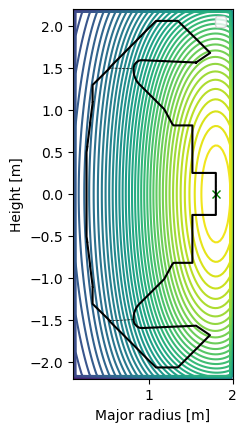

In [26]:
print(len(sim_hist["equilibrium"]))
for i, el in enumerate(sim_hist["equilibrium"]):
    print(f"Equilibrium {i} at time {sim_hist['times'][i]}")
    plot_eqi(el, show=True)

    # print(el.tokamak.getCurrents())
    # print(el.innerOuterSeparatrix())

## Run a validation test

